
# Project: Analyzing World Population and Poverty

In this project, I explored data from [Gapminder.org](http://gapminder.org), a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, but also publishes the raw data that I used in this project to create some of visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the [Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/README.md). Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.

<div class="alert alert-block alert-info" style="margin-top: 20px">

<h2>Table of Contents</h2>

***
   
- [Global Population Growth](#growth)
- [The World](#world)
- [Global Poverty](#global)
- [Author](#author)
    
<p>

</div>

<hr>

In [1]:
# Importing the NumPy and Datascience modules.
from datascience import *
import numpy as np

# Importing the Matplotlib module for plotting.
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Importing the ipywidgets module for interactive widgets.
# This module allows for the creation of interactive controls in Jupyter notebooks.
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

##  Global Population Growth
<a id="growth"></a>


The global population of humans reached 1 billion around 1800, 3 billion around 1960, 7 billion around 2011, and 8 billion around 2022. The potential impact of population growth has concerned scientists, economists, and politicians alike.

The United Nations Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching and stabilizing at 10 billion by 2100. However, the UN does not rule out scenarios of slower or more extreme growth. These projections help us understand long-term population processes, even if they leave out possible global catastrophic events like war or climate crises.

<a href="https://population.un.org/wpp/Graphs/Probabilistic/POP/TOT/900"> 
 <img src="un_population_projection.png"/> 
</a>

In this part, I examined some of the factors that influence population growth and how they have been changing over the years and around the world. There are two main sub-parts:

- First, I examined the data for one country, Poland. I analzyed how factors such as life expectancy, fertility rate, and child mortality have changed over time in Poland, and how they are related to the rate of population growth.
- Second, I examined whether the changes I observed for Poland are particular to that country or whether they reflect general patterns observable in other countries too. Let's study aspects of world population growth and see how they have been changing.


The first table contains the total population of each country over time. The population data can also be found [here](https://www.gapminder.org/data/documentation/gd003/).


In [2]:
population = Table.read_table('population.csv').where("time", are.below(2026))
population.show(3)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000


### Poland

The Central European nation of Poland has undergone many changes over the centuries. In modern times it was (re)created as a democratic republic in 1919 after World War I. It was invaded and divided in World War II between Germany and the Soviet Union. War and the Holocaust had a devastating impact on its people. Poland was constituted in its current borders at the end of World War II (1945) under a communist government. In 1989, with the fall of the Soviet Union, Poland re-established itself as a democratic republic.

In this section, I examined aspects of the population of Poland since 1900. Poland's borders have changed, so I looked at the population within its current (2025) borders.

In the `population` table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard.


 **The Alpha-3 link for Poland is `pol`.**

---

Creating a table called `p_pop` that has two columns labeled `time` and `population_total`. The first column contains the years from 1900 through 2025 and the second column contains the population of Poland in each of those years.


In [3]:
p_pop = population.where("geo", "pol").where("time", are.above_or_equal_to(1900)).select("time", "population_total")
p_pop

time,population_total
1900,24308265
1901,24485193
1902,24660489
1903,24834119
1904,25008969
1905,25185047
1906,25362361
1907,25540920
1908,25720733
1909,25808244


Creating a table called `p_five` that has the population of Poland every five years.


In [4]:
p_pop.set_format('population_total', NumberFormatter)

fives = np.arange(1900, 2026, 5)
p_five = p_pop.sort('time').where('time', are.contained_in(fives))
p_five.show(3)

time,population_total
1900,"24,308,265"
1905,"25,185,047"
1910,"25,803,855"


Visualizing the population over time. Following the devastating effects of World War I and World War II, Poland's population increased steadily from 1950 to 2000 and then leveled off.


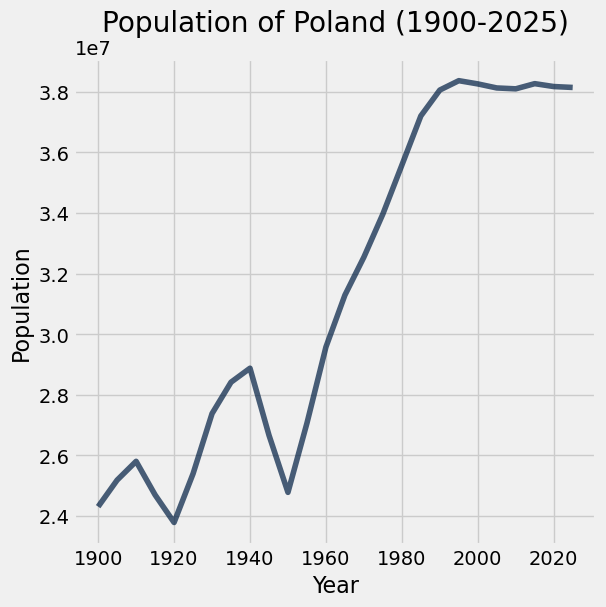

In [35]:
# Plotting the population of Poland from 1900 to 2025.
p_five.plot("time", "population_total")
plots.title("Population of Poland (1900-2025)")
plots.xlabel("Year")
plots.ylabel("Population")
plots.grid(True)    
plots.show()    

---

Assigning `initial` to an array that contains the population for every five year interval from **1900 to 2020** (inclusive). Then, assigning `changed` to an array that contains the population for every five year interval from **1905 to 2025** (inclusive). 

The annual growth rate for a time period is equal to:

$$\left(\left(\frac{\text{Population at end of period}}{\text{Population at start of period}}\right)^{\displaystyle\frac{1}{\text{number of years}}}\right) -1$$

Adding a column to `p_five` called `annual_growth`.


In [6]:
initial = p_five.where("time", are.contained_in(np.arange(1900,2021,5))).column("population_total")
changed = p_five.where("time", are.contained_in(np.arange(1905,2026,5))).column("population_total")

p_1900_through_2020 = p_five.where('time', are.below_or_equal_to(2020)) 
p_five_growth = p_1900_through_2020.with_column('annual_growth', (changed/initial)**0.2-1)
p_five_growth.set_format('annual_growth', PercentFormatter)

time,population_total,annual_growth
1900,"24,308,265",0.71%
1905,"25,185,047",0.49%
1910,"25,803,855",-0.87%
1915,"24,696,678",-0.75%
1920,"23,785,820",1.32%
1925,"25,395,008",1.52%
1930,"27,378,955",0.75%
1935,"28,414,953",0.32%
1940,"28,876,472",-1.58%
1945,"26,666,588",-1.46%


The annual growth rate in Poland has been declining since 1950, as seen in the table below.


In [7]:
# Annual growth rates in Poland since 1955.
p_five_growth.where('time', are.above_or_equal_to(1950)).show()

time,population_total,annual_growth
1950,"24,780,161",1.78%
1955,"27,063,640",1.79%
1960,"29,575,966",1.13%
1965,"31,288,336",0.79%
1970,"32,542,633",0.86%
1975,"33,964,399",0.93%
1980,"35,576,519",0.90%
1985,"37,200,853",0.46%
1990,"38,055,455",0.16%
1995,"38,364,667",-0.06%


Next, I tried to understand what has changed in Poland that might explain the slowing population growth rate.


In [8]:
life_expectancy = Table.read_table('life_expectancy.csv').where('time', are.below(2026))
child_mortality = Table.read_table('child_mortality.csv').relabel(2, 'child_mortality_under_5_per_1000_born').where('time', are.below(2026))
fertility = Table.read_table('fertility.csv').where('time', are.below(2026))

 The `life_expectancy` table contains a statistic that is often used to measure how long people live, called _life expectancy at birth_. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the _mortality conditions_ in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people for each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

The `child_mortality` table has the column _child_mortality_under_5_per_1000_born_ which records the number of children who died before age 5, per 1,000 births.

The `fertility` table contains a statistic that is often used to measure how many babies are being born, the _total fertility rate_. This number describes the [number of children a woman would have in her lifetime](https://www.data4impactproject.org/prh/family-planning/fertility/total-fertility-rate/), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49.

In [9]:
life_expectancy.show(3)

geo,time,life_expectancy_years
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19


In [10]:
child_mortality.show(3)

geo,time,child_mortality_under_5_per_1000_born
afg,1800,468.58
afg,1801,468.58
afg,1802,468.58


In [11]:
fertility.show(3)

geo,time,children_per_woman_total_fertility
afg,1800,7
afg,1801,7
afg,1802,7


<!-- BEGIN QUESTION -->

---

Using the `life_expectancy` table to draw a line graph with the years 1950 and later on the horizontal axis that shows how the _life expectancy at birth_ has changed in Poland.


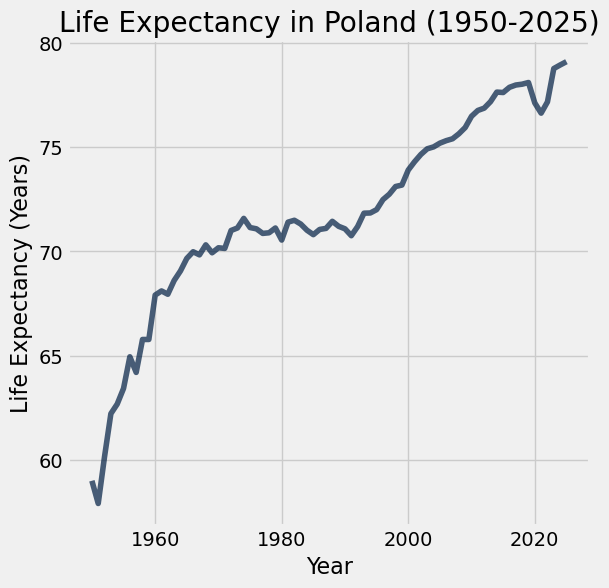

In [36]:
# Plotting the life expectancy in Poland from 1950 to 2025.
poland= life_expectancy.where("geo", "pol").select("time", "life_expectancy_years")
poland_1950 = poland.where("time", are.above_or_equal_to(1950))
poland_1950.plot("time", "life_expectancy_years")
plots.title("Life Expectancy in Poland (1950-2025)")
plots.xlabel("Year")
plots.ylabel("Life Expectancy (Years)")
plots.grid(True)
plots.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---
**Question to ask** Assuming no other factors, such as birth rates or fertility rates, have changed, do the trends in life expectancy in the graph above directly explain why the population growth rate decreased since 1950 in Poland?

#### Analysis 

The increasing trend in life expectancy alone does not directly explain why Poland's population growth rate has decreased since 1950. Looking at the graph of life expectancy, I can clearly observe a steep and significant increase from 58 years around 1950 to nearly 79 years by 2020. That shows that people in Poland are living longer now than they did in the past. However, even though people are living longer lives, which should increase population size, the population growth can still fall if fewer babies are being born. The life expectancy has increased from 58 to 79 years, but the annual growth rate has gone down steadily from 1.78% in 1950 to -0.02% in recent years. If life expectancy were the only factor, we should expect population to keep growing. But that is not what the data shows. This means that, most likely, Poland’s fertility rate would have declined over the same period.

<!-- END QUESTION -->

---

Creating the function `fertility_over_time`. It takes two input arguments, the Alpha-3 code of a country and a year to `start` from. It returns a two-column table with the column labels `Year` and `Children per woman`. These columns can be used to generate a line chart of the country’s fertility rate each year, starting from the year given by `start`. The plot includes the start year and all later years that appear in the fertility table.

The function returns a table which is used in order to plot how Poland's fertility rate has changed since `1950`. 

In [13]:
def fertility_over_time(country_code, start):
    """Creating a two-column table that describes a country's total fertility rate each year."""
    fer_country= fertility.where("geo", country_code).select("time", "children_per_woman_total_fertility").relabeled("time", "Year").relabeled("children_per_woman_total_fertility", "Children per woman")
    fer_country_year= fer_country.where("Year", are.above_or_equal_to(start))
    return fer_country_year
    
poland_code = "pol"
fertility_over_time(poland_code, 1950)

Year,Children per woman
1950,3.66
1951,3.68
1952,3.64
1953,3.6
1954,3.56
1955,3.54
1956,3.45
1957,3.44
1958,3.34
1959,3.21


Plotting the fertility rate in Poland since 1950.


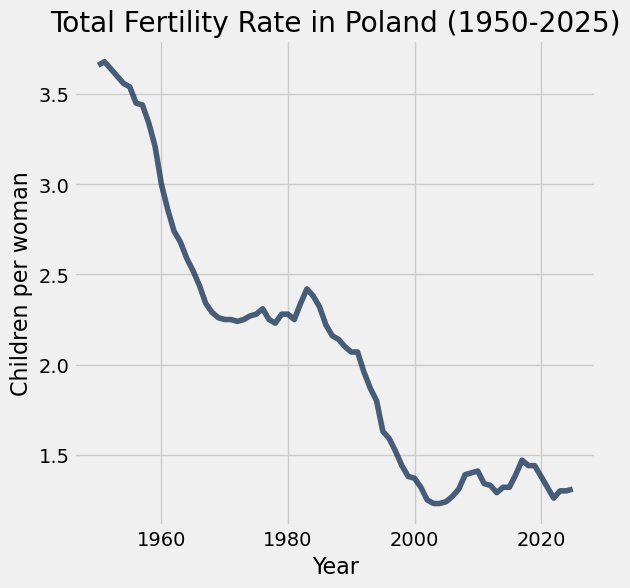

In [38]:
fertility_over_time(poland_code, 1950).plot("Year", "Children per woman")
plots.title("Total Fertility Rate in Poland (1950-2025)")
plots.xlabel("Year")
plots.ylabel("Children per woman")
plots.grid(True)
plots.show()

We can clearly see a downward trend.

<!-- BEGIN QUESTION -->

---

**Question** Assuming everything else is constant, do the trends in fertility in the graph above help directly explain why the population growth rate decreased since 1950 in Poland?


#### Analysis

As seen through the graph, the trend in fertility directly explains why Poland's population growth rate has decreased since 1950. The graph shows a clear, steady decline in fertility rate from 3.7 children per woman in 1950 to just 1.3 by 2020, which is a huge drop. Since fertility rate is a direct measure of how many children are being born, this decline directly affects how fast the population grows. If women are having fewer children on average, then over time, fewer babies are born, which means fewer young people to replace the older generation. Even if people live longer as seen in the life expectancy graph, the population will grow more slowly if there aren’t enough births to balance it out. This supports the decrease in population growth rate from 1.78% in 1950 to -0.02% in 2020.

<!-- END QUESTION -->

It has been [observed](https://www.ageing.ox.ac.uk/download/143) that lower fertility rates are often associated with lower child mortality rates. Checking if this association is evident in Poland by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).


---

Creating a table `poland_since_1950` that contains one row per year starting with 1950, column `Year` containing the year, column `Children per woman` describing total fertility in Poland that year, and column `Child deaths per 1000 born` describing child mortality in Poland that year.


In [15]:
pol_fertility = fertility_over_time(poland_code, 1950) 
pol_child_mortality = child_mortality.where("geo", "pol").where("time", are.above_or_equal_to(1950)).column("child_mortality_under_5_per_1000_born")
pol_fertility_and_child_mortality = pol_fertility.with_column("Child deaths per 1000 born", pol_child_mortality)
poland_since_1950 = pol_fertility_and_child_mortality
poland_since_1950.show(10)

Year,Children per woman,Child deaths per 1000 born
1950,3.66,164.08
1951,3.68,177.18
1952,3.64,140.16
1953,3.6,127.65
1954,3.56,118.9
1955,3.54,110.38
1956,3.45,94.19
1957,3.44,86.72
1958,3.34,81.28
1959,3.21,72.1


Creating a scatter plot from the `poland_since_1950` table I created.

The plot uses **color** to encode data about the `Year` column. The colors, ranging from dark blue to white, represent the passing of time between 1950 and 2025. For example, a point on the scatter plot representing data from the 1950s would appear as **dark blue** and a point from the 2010s would appear as **light blue**.


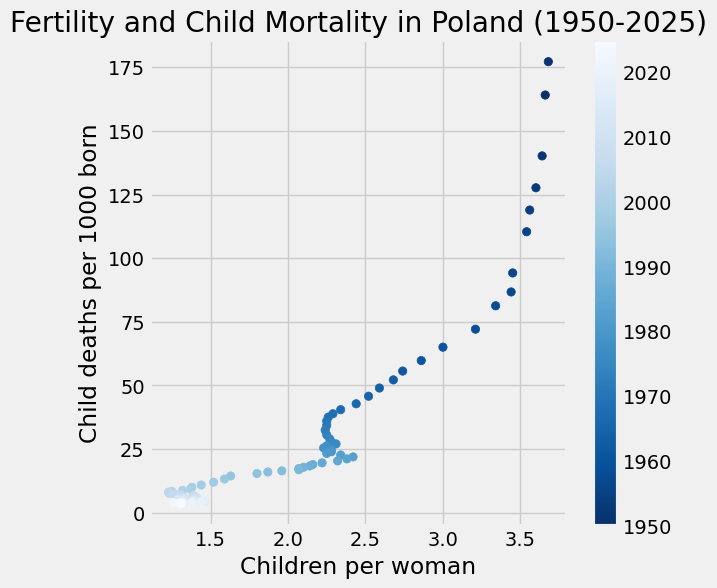

In [43]:
# Plotting the relationship between fertility and child mortality in Poland since 1950.
x_births = poland_since_1950.column("Children per woman")
y_deaths = poland_since_1950.column("Child deaths per 1000 born")
time_colors = poland_since_1950.column("Year")

plots.figure(figsize=(6,6))
plots.scatter(x_births, y_deaths, c=time_colors, cmap="Blues_r")
plots.colorbar()                  
plots.xlabel("Children per woman")
plots.ylabel("Child deaths per 1000 born")
plots.title("Fertility and Child Mortality in Poland (1950-2025)")
plots.grid(True)
plots.show();

#### Analysis:

The scatter plot shows a clear positive association between fertility and child mortality as child mortality decreases, fertility also decreases as time goes from 1950 to 2020. However, while the graph shows this strong relationship, it does not prove a direct causal link. Other confounding factors or variables, like healthcare improvements and economic development, could be influencing both variables at the same time. So, while lower child mortality may contribute to lower fertility, we can not say for sure from the graph alone that one causes the other.

To better understand the factors affecting life expectancy, child mortality, and fertility, we need to analyze the distribution of wealth and access to economic opportunities to explain disparities within and between populations. We also need information on the availability, quality, and affordability of healthcare services and factors like education levels and food security.

<hr style="border: 1px solid #fdb515;" />

# The World 

<a id= "world"></a>

The changes observed in Poland can also be observed in many other countries: except during periods of extended war, famine, and social chaos, health services generally improve, life expectancy increases, and child mortality decreases. At the same time, the fertility rate often plummets, and where it does, the population growth rate decreases despite increasing longevity.

Creating two overlaid histograms, one for 1962 and one for 2010, that show the distributions of total fertility rates for these two years among all 201 countries in the `fertility` table.

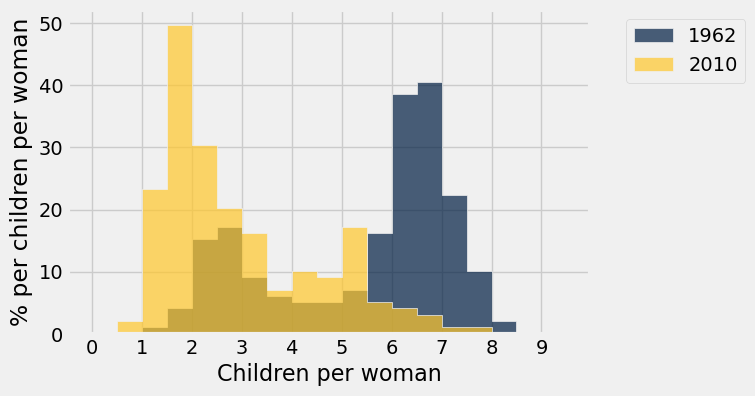

In [48]:
Table().with_columns( 
    '1962', fertility.where('time', 1962).column(2),
    '2010', fertility.where('time', 2010).column(2)
).hist(bins=np.arange(0, 10, 0.5), unit='child per woman')
_ = plots.xlabel('Children per woman')
_ = plots.ylabel('% per children per woman')
_ = plots.xticks(np.arange(10))

---

#### Analysis

1. In 1962, less than 20% of countries had a fertility rate below 3.
1. At least half of countries had a fertility rate between 5 and 8 in 1962.
1. At least half of countries had a fertility rate below 3 in 2010.
1. More countries had a fertility rate above 3 in 1962 than in 2010.


<!-- BEGIN QUESTION -->

---

Creating a line plot of the **world population** from 1800 through 2025 (inclusive of both endpoints).


In [62]:
population.show(5)

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000
afg,1803,3280000
afg,1804,3280000


In [72]:
population.sort("time", descending=True)

geo,time,population_total
afg,2100,130216739
alb,2100,1184997
dza,2100,64487527
and,2100,47222
ago,2100,150045574
atg,2100,67975
arg,2100,38255990
arm,2100,1692198
aus,2100,43143685
aut,2100,7399328


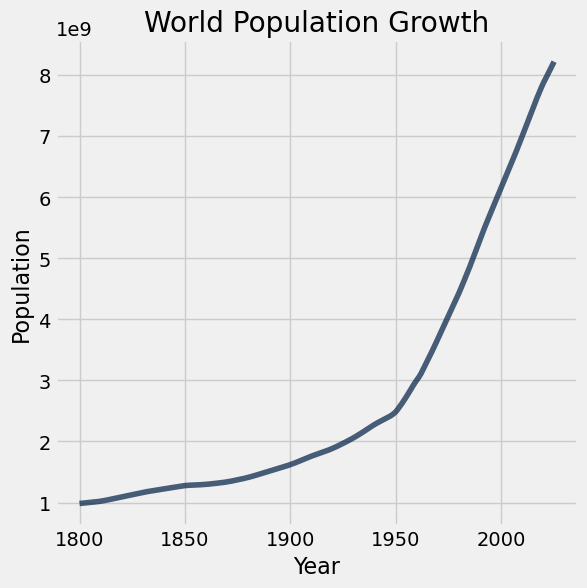

In [74]:
popu_time = population.group("time", sum).select("time", "population_total sum").relabeled("population_total sum", "population_total")
popu_time = popu_time.relabeled("time", "Year").where("Year", are.between_or_equal_to(1800, 2025))
popu_time.plot("Year", "population_total")
plots.title("World Population Growth")
plots.xlabel("Year")
plots.ylabel("Population")
plots.grid(True)
plots.show()

<!-- END QUESTION -->

---

Creating a function `stats_for_year` that takes a `year` and returns a table of statistics. Each row contains one unique Alpha-3 country code and three statistics: population, fertility rate, and child mortality for that `year` from the `population`, `fertility` and `child_mortality` tables. 

In addition, I restricted the result to the 50 most populous countries in 2025.


In [20]:
# Creating a population table that only includes the 
# 50 countries with the largest 2025 populations.
big_50 = population.where('time', are.equal_to(2025)).sort("population_total", descending=True).take(np.arange(50)).sort("geo").column('geo')
population_of_big_50 = population.where('time', are.above(1959)).where('geo', are.contained_in(big_50))

def stats_for_year(year):
    """Return a table of the stats for each country that year."""
    p = population_of_big_50.where('time', are.equal_to(year)).drop('time')
    f = fertility.where('time', are.equal_to(year)).drop('time')
    c = child_mortality.where('time', are.equal_to(year)).drop('time')
    stats= Table().with_columns("geo", big_50, 
                               "population_total", p.sort("geo").column("population_total"),
                               "children_per_woman_total_fertility", f.where('geo', are.contained_in(big_50)).sort("geo").column("children_per_woman_total_fertility"),
                               "child_mortality_under_5_per_1000_born", c.where('geo', are.contained_in(big_50)).sort("geo").column("child_mortality_under_5_per_1000_born"))
    return stats.sort("population_total", descending=True)
stats_for_year(1970)

geo,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
chn,823308967,6.09,112.59
ind,545864268,5.62,213.58
usa,207796339,2.52,23.25
rus,130367189,2.01,38.16
idn,115657495,5.49,165.98
jpn,106712368,2.04,17.45
bra,95375651,4.93,132.5
deu,78205102,2.02,25.66
bgd,69058894,6.84,223.13
pak,60166719,6.8,190.54


---

Creating a table called `pop_by_decade` with two columns `decade` and `population`. It has a row for each year that starts a decade, in increasing order starting with 1960 and ending with 2020. 

In [21]:
def pop_for_year(year):
    """Return the total population for the specified year."""
    return np.sum(stats_for_year(year).column("population_total"))
    
pop_for_year(1960)

2604997601

In [22]:
decades = Table().with_column('decade', np.arange(1960, 2021, 10))
pop_by_decade = decades.with_column("population", decades.apply(pop_for_year, 'decade'))
pop_by_decade.set_format(1, NumberFormatter)

decade,population
1960,"2,604,997,601"
1970,"3,202,277,698"
1980,"3,863,485,128"
1990,"4,639,963,324"
2000,"5,381,686,829"
2010,"6,107,215,351"
2020,"6,840,687,359"


The `countries` table describes various characteristics of countries. The `country` column contains the same codes as the `geo` column in each of the other data tables (`population`, `fertility`, and `child_mortality`). The `world_6region` column classifies each country into a region of the world.

In [23]:
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
countries.select('country', 'name', 'world_6region')

country,name,world_6region
afg,Afghanistan,south_asia
ago,Angola,sub_saharan_africa
alb,Albania,europe_central_asia
and,Andorra,europe_central_asia
are,United Arab Emirates,middle_east_north_africa
arg,Argentina,america
arm,Armenia,europe_central_asia
atg,Antigua and Barbuda,america
aus,Australia,east_asia_pacific
aut,Austria,europe_central_asia


---

Creating a table called `region_counts`. It contains two columns called `region` and `count` which contains the number of countries in each region that appears in the result of `stats_for_year(2025)`. 


In [24]:
stats_for_2025 = countries.where("country", are.contained_in(stats_for_year(1970).column("geo"))).group("world_6region").relabel("world_6region", "region")
region_counts = Table().with_columns("region", stats_for_2025.column("region"),"count", stats_for_2025.column("count"))
region_counts

region,count
america,7
east_asia_pacific,9
europe_central_asia,10
middle_east_north_africa,7
south_asia,4
sub_saharan_africa,13


Creating a scatter plot diagram  that compares total fertility rate and child mortality rate for each country in 1960. The area of each dot represents the population of the country, and the color represents its region of the world.

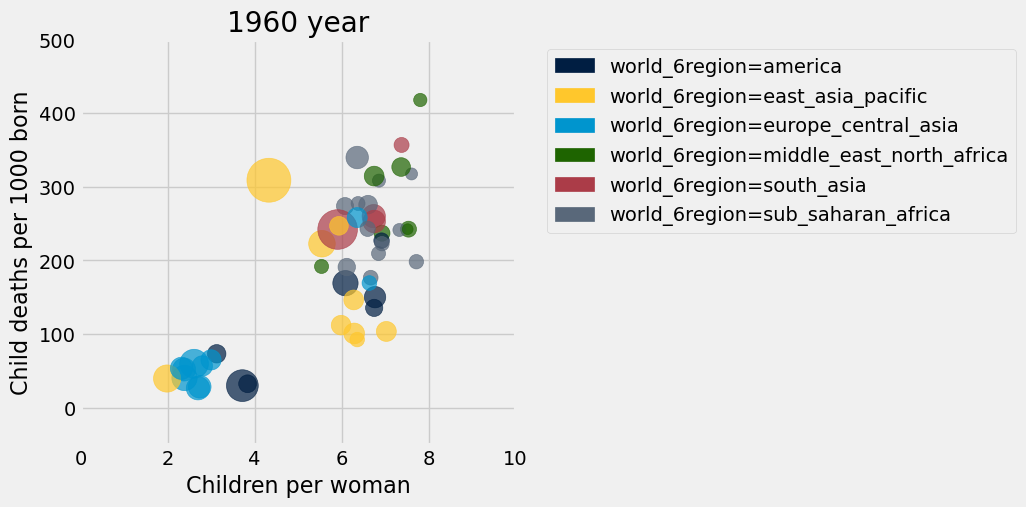

In [76]:
from functools import lru_cache as cache

# Caching the stats_for_year function to avoid recomputing it multiple times.
# This cache annotation makes sure that if the same year
# is passed as an argument twice, the work of computing
# the result is only carried out once.
@cache(None)
def stats_relabeled(year):
    """Relabeled and cached version of stats_for_year."""
    return stats_for_year(year).relabel(2, 'Children per woman').relabel(3, 'Child deaths per 1000 born')

def fertility_vs_child_mortality(year):
    """Draw a color scatter diagram comparing child mortality and fertility."""
    with_region = stats_relabeled(year).join('geo', countries.select('country', 'world_6region'), 'country')
    with_region.scatter(2, 3, sizes=1, group=4, s=500)
    plots.xlim(0,10)
    plots.ylim(-50, 500)
    plots.title(f"{year} year")
    plots.show()

fertility_vs_child_mortality(1960)

---

#### Analysis:


1. Most countries had a fertility rate above 5.
1. There was an association between child mortality and fertility.


I used `widgets` to makes the result interactive. Drag the slider to see how countries have changed over time. It is noticable that in terms of population growth, the divide between the countries of the global North and global South that existed in the 1960s has shrunk significantly. 

This shift in fertility rates is the reason that the global population is expected to grow more slowly in the 21st century than it did in the 19th and 20th centuries. Fertility rates change for reasons that include cultural patterns, better prospects for children surviving to adulthood, and family planning (such as contraception and women’s greater control over their reproduction).

In [77]:
_ = widgets.interact(fertility_vs_child_mortality, 
                     year=widgets.IntSlider(min=1960, max=2025, value=1960));

interactive(children=(IntSlider(value=1960, description='year', max=2025, min=1960), Output()), _dom_classes=(…

When we look at population and fertility as a data scientists, we need to learn about the experiences of people in real life, not just abstractly as data. We should also recognize that population studies have sometimes had political undercurrents. Those undercurrents have included population control, control of women’s reproduction, or fears of shifts between racial groups. To do better as data scientists, we should check our assumptions to avoid unthinkingly reproducing past patterns.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Global Poverty

<a id="global"></a>

In 1800, 85% of the world's 1 billion people lived in [extreme poverty](https://en.wikipedia.org/wiki/Extreme_poverty), defined by the United Nations as "a condition characterized by severe deprivation of basic human needs, including food, safe drinking water, sanitation facilities, health, shelter, education and information." At the time when the data in this project were gathered, a common definition of extreme poverty was a person living on less than \$1.25 a day.

In 2018, the proportion of people living in extreme poverty was estimated to be [about 9\%](https://unstats.un.org/sdgs/report/2019/goal-01/). Although the world rate of extreme poverty has declined consistently for hundreds of years, the number of people living in extreme poverty is still over 600 million. The United Nations adopted an [ambitious goal](http://www.un.org/sustainabledevelopment/poverty/): "By 2030, eradicate extreme poverty for all people everywhere."

In this part, I examined some aspects of global poverty that might affect whether the goal is achievable. The causes of poverty are complex. They include global histories, such as colonialism, as well as factors such as health care, economics, and social inequality in each country.

First, loading the population and poverty rate by country and year and the country descriptions. While the `population` table has values for every recent year for many countries, the `poverty` table only includes certain years for each country in which a measurement of the rate of extreme poverty was available.

In [27]:
population = Table.read_table('population.csv') 
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
poverty = Table.read_table('poverty.csv')
poverty.show(3)

geo,time,extreme_poverty_percent_people_below_125_a_day
alb,1996,0.2
alb,2002,0.73
alb,2004,0.53


---

Creating `latest_poverty` as a three-column table with one row for each country that appears in the `poverty` table. The first column contains the 3-letter code for the country, second column contains the most recent year for which an extreme poverty rate is available for the country, and third column contains the poverty rate in that year.

In [28]:
def first(values):
    return values.item(0)  
    
latest_poverty = poverty.sort('time', descending=True).group('geo', first)
latest_poverty = latest_poverty.relabeled(0, 'geo').relabeled(1, 'time').relabeled(2, 'poverty_percent') # You should *not* change this line.
latest_poverty

geo,time,poverty_percent
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


---

Using both `latest_poverty` and `population`to create a four-column table called `recent_poverty_total` with one row for each country. `geo` contains the 3-letter country code, `poverty_percent` contains the most recent poverty percent, `population_total` contains the population of the country in 2010, `poverty_total` contains the number of people in poverty rounded to the nearest integer, based on the 2010 population and most recent poverty rate.

In [29]:
poverty_and_pop = latest_poverty.join('geo', population.where('time', 2010), 'geo').drop('time').drop("time_2")
recent_poverty_total = poverty_and_pop.with_column("poverty_total", 
                                                   np.round(poverty_and_pop.column("poverty_percent") * poverty_and_pop.column("population_total")/100))

recent_poverty_total

geo,poverty_percent,population_total,poverty_total
ago,43.37,23294825,1.0103e+07
alb,0.46,2928722,13472
arg,1.41,41288694,582171
arm,1.75,2931078,51294
aus,1.36,22141581,301126
aut,0.34,8365092,28441
aze,0.31,9146851,28355
bdi,81.32,9376444,7.62492e+06
bel,0.5,10936626,54683
ben,51.61,9797484,5.05648e+06


---

Assigning the name `poverty_percent` to the known percentage of the world’s 2010 population that were living in extreme poverty. Assuming that the `poverty_total` numbers in the `recent_poverty_total` table describe **all** people in 2010 living in extreme poverty. 

**Note:** The sum of the `population_total` column in the `recent_poverty_total` table is not the world population, because only a subset of the world's countries are included in the `recent_poverty_total` table (only some countries have known poverty rates).


In [30]:
population

geo,time,population_total
afg,1800,3280000
afg,1801,3280000
afg,1802,3280000
afg,1803,3280000
afg,1804,3280000
afg,1805,3280000
afg,1806,3280000
afg,1807,3280000
afg,1808,3280000
afg,1809,3280000


In [79]:
poverty_percent = (sum(recent_poverty_total.column("poverty_total"))/ sum(population.where("time", 2010).column("population_total")))*100
print(f"The global poverty percentage is {np.round(poverty_percent, 2)}%.")

The global poverty percentage is 14.43%.


The `countries` table includes the name, region, and also their positions on the globe.

In [80]:
countries.select('country', 'name', 'world_4region', 'latitude', 'longitude')

country,name,world_4region,latitude,longitude
afg,Afghanistan,asia,33,66
ago,Angola,africa,-12.5,18.5
alb,Albania,europe,41,20
and,Andorra,europe,42.5078,1.52109
are,United Arab Emirates,asia,23.75,54.5
arg,Argentina,americas,-34,-64
arm,Armenia,europe,40.25,45
atg,Antigua and Barbuda,americas,17.05,-61.8
aus,Australia,asia,-25,135
aut,Austria,europe,47.3333,13.3333


---

Using both `countries` and `recent_poverty_total` tables, I created a five-column table called `poverty_map` with one row for every country. 

1. `latitude` contains the country's latitude,
1. `longitude` contains the country's longitude,
1. `name` contains the country's name,
1. `region` contains the country's region from the `world_4region` column of `countries`,
1. `poverty_total` contains the country's poverty total.


In [81]:
poverty_map = recent_poverty_total.join("geo", countries, "country").select("latitude", "longitude", "name", "world_4region", "poverty_total").relabeled("world_4region", "region")
poverty_map

latitude,longitude,name,region,poverty_total
-12.5,18.5,Angola,africa,1.0103e+07
41,20,Albania,europe,13472
-34,-64,Argentina,americas,582171
40.25,45,Armenia,europe,51294
-25,135,Australia,asia,301126
47.3333,13.3333,Austria,europe,28441
40.5,47.5,Azerbaijan,europe,28355
-3.5,30,Burundi,africa,7.62492e+06
50.75,4.5,Belgium,europe,54683
9.5,2.25,Benin,africa,5.05648e+06


Creating a map of the world in which the areas of circles represent the number of people living in extreme poverty.

In [96]:
# Creating a map of the world in which the areas of circles represent the number of people living in extreme poverty.
from datascience import Circle


colors = {'africa': 'blue', 'europe': 'black', 'asia': 'red', 'americas': 'green'}
scaled = poverty_map.with_columns(
    'labels', poverty_map.column('name'),
    'colors', poverty_map.apply(colors.get, 'region'),
    'areas', 1e-4 * poverty_map.column('poverty_total')
).drop('name', 'region', 'poverty_total')

Circle.map_table(scaled)

Although people lived in extreme poverty throughout the world in 2010 (with more than 5 million in the United States), the largest numbers were in Asia and Africa.

---

Assigning `largest` to a two-column table with the `name` and `poverty_total` of the 10 countries with the largest number of people living in extreme poverty.


In [83]:
largest = poverty_map.sort("poverty_total", descending=True).select("name", "poverty_total").take(np.arange(10))
largest.set_format('poverty_total', NumberFormatter)

name,poverty_total
India,"293,834,694.00"
Nigeria,"103,368,582.00"
China,"84,607,751.00"
Bangladesh,"65,827,357.00"
"Congo, Dem. Rep.","60,143,497.00"
Indonesia,"39,901,462.00"
Ethiopia,"33,309,119.00"
Pakistan,"25,383,055.00"
Tanzania,"19,460,991.00"
Madagascar,"19,448,134.00"


<!-- BEGIN QUESTION -->

---

It is important to study the absolute number of people living in poverty, not just the percent. The absolute number is an important factor in determining the amount of resources needed to support people living in poverty. 

I wrote a function called `poverty_timeline` that takes **the name of a country** as its argument (not the Alpha-3 country code). It draws a line plot of the number of people living in poverty in that country with time on the horizontal axis. 

To compute the population living in poverty from a poverty percentage, I multiplied by the population of the country **in that year**.

The function displays a line plot showing the absolute number of people living in poverty in a given country over time. The x-axis should represent years, and the y-axis should represent the number of people living in poverty.

#### Steps:

1. Joining poverty and countries tables to match each row in the poverty table with the country’s name.

2. Joining with population table to get the total population for each country-year pair to calculate the absolute number of people in poverty.

3. Sorting by time to ensure the plot is chronological and makes the trend over time clear and easy to interpret.

4. Calculating absolute poverty numbers to find the actual number of people living in poverty by multipling the poverty percentage by the population for each year.

5. Filtering for the selected country and plot to focus on the variable country and to plot the timeline.

In [84]:
pov = poverty.join("geo", countries.select("country", "name"), "country")
pov= pov.join(["geo", "time"], population, ["geo", "time"])
pov= pov.sort("time")
pov.with_column("poverty_total", pov.column("extreme_poverty_percent_people_below_125_a_day") * pov.column("population_total"))

geo,time,extreme_poverty_percent_people_below_125_a_day,name,population_total,poverty_total
ind,1978,65.89,India,655728229,4.32059e+10
isr,1979,0,Israel,3640874,0
pan,1979,7.98,Panama,1911552,1.52542e+07
col,1980,15.45,Colombia,26104498,4.03314e+08
esp,1980,0.67,Spain,37537565,2.51502e+07
mdg,1980,94.64,Madagascar,9006032,8.52331e+08
aus,1981,0.67,Australia,14949202,1.0016e+07
bra,1981,13.64,Brazil,124063109,1.69222e+09
can,1981,0.68,Canada,24844974,1.68946e+07
chn,1981,84.27,China,997721071,8.4078e+10


In [95]:
def population_for_country_in_year(row_of_poverty_table):
    """return the population of a country in a year using a row from the poverty table."""
    return population.where('geo',row_of_poverty_table.column('geo'
    ).item(0)).where('time', row_of_poverty_table.column('time'
    ).item(0)).column('population_total').item(0)
    
def poverty_for_country(country):
    """Display the poverty percentage for a country in 2010."""
    row_of_poverty_table = poverty.where("country", country).where("time", 2010).row(0)
    population_total = population_for_country_in_year(row_of_poverty_table)
    poverty_percent = row_of_poverty_table.column("extreme_poverty_percent_people_below_125_a_day").item(0)
    poverty_total = np.round(poverty_percent * population_total / 100)
    print(f"In {country}, {poverty_total} people lived in extreme poverty in 2010.")

@interact(country=countries.select("name").column("name"))
def poverty_timeline(country="India"):
    """Draw a timeline of people living in extreme poverty in a country."""
    pov = poverty.join("geo", countries.select("country", "name"), "country")
    pov= pov.join(["geo", "time"], population, ["geo", "time"])
    pov= pov.sort("time")
    pov= pov.with_column("poverty_total", pov.column("extreme_poverty_percent_people_below_125_a_day") * pov.column("population_total"))
    pov.where("name", country).select("time", "poverty_total").plot("time")
    plots.title(country)
    plots.xlabel("Year")
    plots.ylabel("Total Poverty")
    plots.ylim(bottom=0)
    plots.show()

interactive(children=(Dropdown(description='country', index=79, options=('Afghanistan', 'Angola', 'Albania', '…

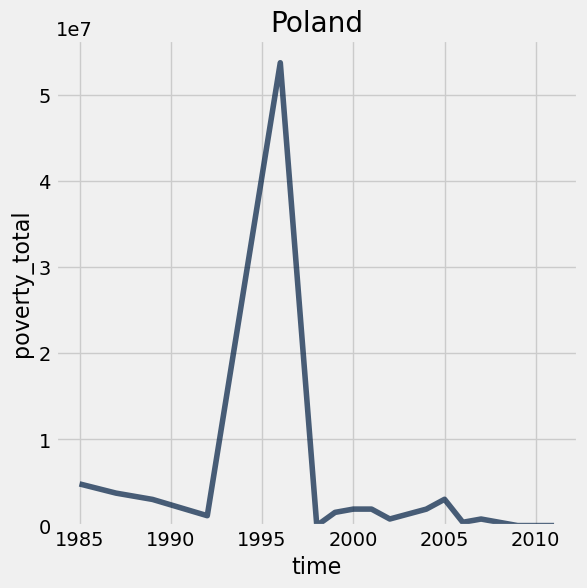

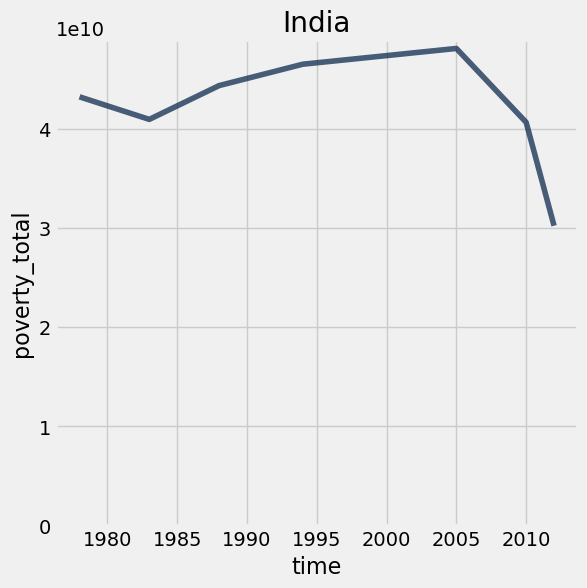

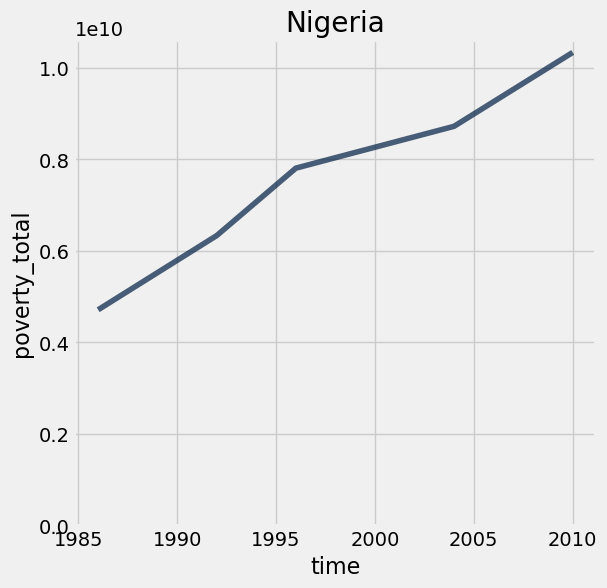

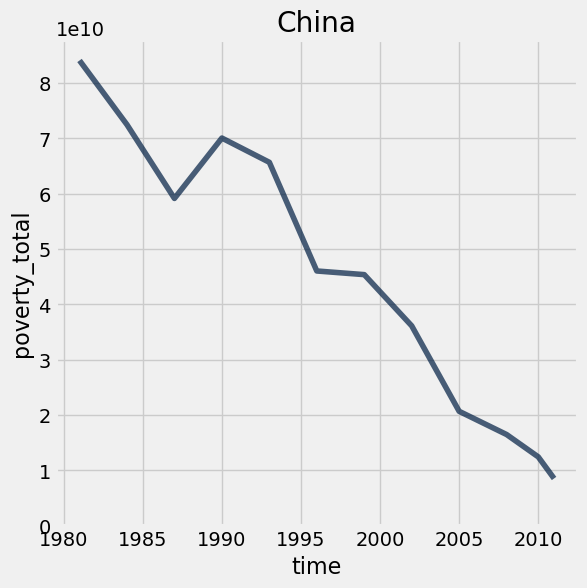

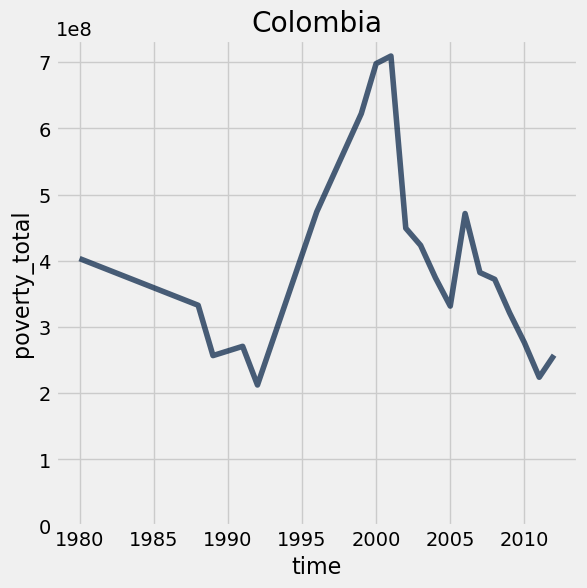

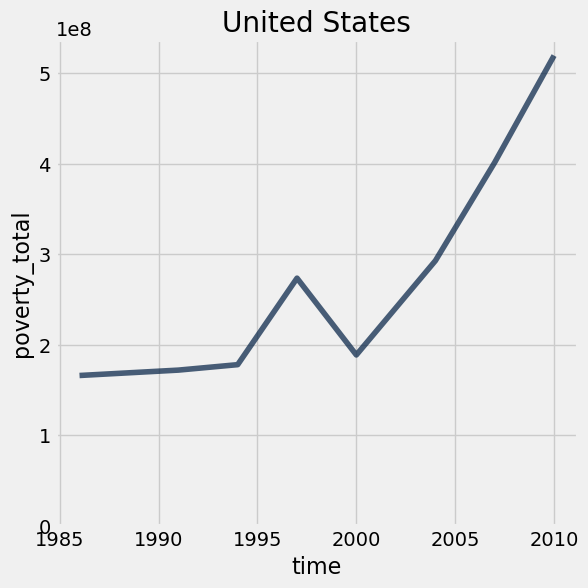

In [93]:
poverty_timeline('Poland')
poverty_timeline('India')
poverty_timeline('Nigeria')
poverty_timeline('China')
poverty_timeline('Colombia')
poverty_timeline('United States')

<!-- END QUESTION -->

Although the number of people living in extreme poverty increased in some countries including Nigeria and the United States, the decreases in other countries, most notably the massive decreases in China and India, have shaped the overall trend that extreme poverty is decreasing worldwide, both in percentage and in absolute number. 


Below, I added an interactive dropdown menu to visualize `poverty_timeline` graphs for other countries.

In [97]:
# Creating an interactive dropdown menu to visualize poverty timelines for all countries.
all_countries = poverty_map.column('name')
_ = widgets.interact(poverty_timeline, country=list(all_countries))

interactive(children=(Dropdown(description='country', index=63, options=('Angola', 'Albania', 'Argentina', 'Ar…

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />



## Author
<a id="author"></a>

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b) 